# LeNet class implementation in keras

We'll use tensorflow.keras to implement LeNet class in this file.

Let's import required modules for it.

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

Now we create a sequential model that has all the layers from LeNet.

In [6]:
model = Sequential([
            Input(shape=(28, 28, 1)),
            Conv2D(filters=6, kernel_size=(5,5), 
                    activation='sigmoid', # input_shape=(28, 28, 1), 
                    padding='same'),
            AveragePooling2D(pool_size=(2, 2), strides=2),
            Conv2D(filters=16, kernel_size=(5,5), 
                    activation='sigmoid', 
                    padding='same'),
            AveragePooling2D(pool_size=(2, 2), strides=2),
            Flatten(),
            Dense(120, activation='sigmoid'),
            Dense(84, activation='sigmoid'),
            Dense(10, activation='softmax')
        ])

Next the model needs to be compiled using compile() function and then train using fit() function.

We need to give 3 parameters to compile function.
1. Optimizer
2. loss
3. metrics

In [7]:
model.compile(optimizer='Adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

Now lets train our model. For training we need mnist dataset.

Keras has datasets class where we can find mnist dataset.

In [8]:

from tensorflow.keras.datasets import mnist

In [9]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [10]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


We need to reshape our test and train image and labels to match the requirements of the model.

In [11]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)  
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)  

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

to_categorical function will return one-hot encoding of the labels.

Let's normalize.

In [12]:
x_train = x_train/255.0
x_test = x_test/255.0

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28, 1)
(60000, 10)
(10000, 28, 28, 1)
(10000, 10)


We use fit function to train our model.

Fit function will take 4 parametes.
1. training data
2. target data
3. epochs
4. batch size

In [13]:
batch_size=32
epochs=20

In [14]:
model.fit(x_train, y_train, batch_size, epochs)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4815 - loss: 1.4567
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9374 - loss: 0.2043
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9625 - loss: 0.1228
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9725 - loss: 0.0926
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9784 - loss: 0.0695
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9818 - loss: 0.0584
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9839 - loss: 0.0484
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9857 - loss: 0.0452
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9891 - loss: 0.0361
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9892 - loss: 0.0363
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9912 - loss: 0.0283
Epoch 12/20
1875/1875 ━━━━━━━

Let's test our model using mnist test images. We use predict() function to test our model.

In [15]:
predictions = model.predict(x_test[0:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


In [16]:
print(predictions)

[[5.94864513e-09 1.27925802e-07 6.78318202e-09 1.14060846e-07
  2.96814950e-09 1.81699433e-09 5.95059348e-14 9.99999285e-01
  1.10408038e-09 4.06868480e-07]
 [1.62250763e-06 1.32955313e-06 9.99996781e-01 5.08372944e-09
  9.46505185e-09 9.46054624e-11 2.62884356e-07 9.31877064e-09
  2.80077490e-08 4.98799502e-10]
 [1.01038360e-08 9.99992371e-01 1.30845464e-07 1.18446342e-09
  2.86217892e-06 1.99759516e-08 6.90977657e-08 1.22952008e-06
  3.42116846e-06 4.52699611e-09]
 [9.99984741e-01 1.04369291e-10 3.04769600e-07 3.29382721e-09
  4.87444858e-08 2.13365237e-08 6.79770301e-06 2.75315770e-08
  4.02319493e-08 8.05772743e-06]
 [7.93227883e-08 7.46433557e-07 7.87447107e-07 2.28216934e-09
  9.99741137e-01 3.62596495e-08 7.84647284e-07 5.51803896e-06
  5.07211666e-07 2.50428304e-04]
 [3.16652766e-08 9.99952674e-01 4.23954596e-08 6.20981488e-10
  2.62950234e-05 6.18580742e-09 2.01823056e-08 1.17013324e-05
  9.10622111e-06 8.36309866e-08]
 [1.32104940e-08 7.99253394e-06 7.75087415e-07 6.59985702e

In [17]:
import numpy as np

In [18]:
predictions = np.argmax(predictions,axis=1)

In [19]:
labels = np.argmax(y_test[0:10], axis=1)

In [20]:
print(predictions == labels)

[ True  True  True  True  True  True  True  True  True  True]


Let's save our model in our local system using save function.

In [23]:
model_path = 'lenet_model.keras'

In [24]:
model.save(model_path)

Now load our saved model and test again.

In [25]:
from tensorflow.keras.models import load_model
loaded_model = load_model(model_path)

In [26]:
predictions_2 = np.argmax(loaded_model.predict(x_test[0:10]),axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


In [27]:
print(predictions_2)
print(labels)

[7 2 1 0 4 1 4 9 5 9]
[7 2 1 0 4 1 4 9 5 9]


In [28]:
print(predictions == labels)

[ True  True  True  True  True  True  True  True  True  True]


Now using all the commands above let's create a class for LeNet.

## LeNet class

In [29]:
import os
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np

In [30]:
class LeNet:
    def __init__(self, batch_size=32, epochs=20):
        self.batch_size = batch_size
        self.epochs = epochs
        self.model = None
        self._create_lenet()
        self._compile()
    
    def _create_lenet(self):
        self.model = Sequential([
            Input(shape=(28, 28, 1)),
            Conv2D(filters=6, kernel_size=(5,5), 
                    activation='sigmoid', # input_shape=(28, 28, 1), 
                    padding='same'),
            AveragePooling2D(pool_size=(2, 2), strides=2),
            
            Conv2D(filters=16, kernel_size=(5,5), 
                    activation='sigmoid', 
                    padding='same'),
            AveragePooling2D(pool_size=(2, 2), strides=2),

            Flatten(),

            Dense(120, activation='sigmoid'),
            Dense(84, activation='sigmoid'),
            Dense(10, activation='softmax')
        ])

    def _compile(self):
        if self.model is None:
            print('Error: Create a model first..')
        
        self.model.compile(optimizer='Adam',
                            loss='categorical_crossentropy',
                            metrics=['accuracy'])
        

    def _preprocess(self):
        # load mnist data
        (x_train, y_train), (x_test, y_test) = mnist.load_data()

        # normalize
        x_train = x_train/255.0
        x_test = x_test/255.0

        # add channel dim
        self.x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)  
        self.x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)  

        # one-hot encoding
        self.y_train = to_categorical(y_train, 10)
        self.y_test = to_categorical(y_test, 10)

    def train(self):
        self._preprocess()
        self.model.fit(self.x_train, self.y_train, 
                    batch_size=self.batch_size, 
                    epochs=self.epochs)
        
    def save(self, model_path_name):
        if os.path.exists(f'{model_path_name}'):
            pass
        else:
            self.model.save(model_path_name)
    
    def load(self,model_path_name):
        if os.path.exists(f'{model_path_name}'):
            self.loaded_model = load_model(model_path_name)
        
    def predict(self,images):
        # predictions = np.argmax(self.loaded_model.predict(images), axis=1)
        predictions = self.loaded_model.predict(images)
        return predictions

Now let's use this class.

In [31]:
network = LeNet(batch_size=64, epochs=20)

In [32]:
if os.path.exists(f'{model_path}'):
        pass
else:
    network.train()

In [33]:
network.save(model_path)
network.load(model_path)

In [34]:
y_hat = network.predict(x_test[0:16])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [35]:
print(np.argmax(y_hat,axis=1))

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5]


In [36]:
np.argmax(y_test[0:16],axis=1)

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5], dtype=int64)

In [37]:
predictions = np.argmax(network.predict(x_test[0:10]), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [38]:
labels = np.argmax(y_test[0:10], axis=1)

In [39]:
print(predictions == labels)

[ True  True  True  True  True  True  True  True  True  True]


Let's create a separate file for this class test it with custom images.

In [40]:
from le_net import LeNet

In [44]:
model_path_name = 'lenet_model.keras'

In [42]:
le_net = LeNet()

In [45]:
le_net.train()
le_net.save(model_path_name)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9960 - loss: 0.0120
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9967 - loss: 0.0104
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9965 - loss: 0.0100
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9974 - loss: 0.0083
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9978 - loss: 0.0071
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9970 - loss: 0.0086
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9978 - loss: 0.0073
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9973 - loss: 0.0069
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9975 - loss: 0.0075
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9980 - loss: 0.0056
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9979 - loss: 0.0066
Epoch 12/20
1875/187

In [ ]:
le_net.load(model_path_name)

In [ ]:
image_filename = "C:\\MS-AI\\parternRecogNN\\ece5831-2024-assignments\\08\\Custom MNIST Samples\\Digit 2\\2_2.png"

In [ ]:
from PIL import Image

In [ ]:
grayscale_image = Image.open(image_filename).convert('L')
resized_image = grayscale_image.resize((28, 28))  # Resize to 28x28
image_data = np.array(resized_image).astype(np.float32)
image_data = image_data.flatten() / 255.0  # Normalize

In [ ]:
image_data = image_data.reshape(1, 28,28)
y_hat = network.predict(image_data)
y_hat = np.argmax(y_hat)

In [ ]:
import matplotlib.pyplot as plt

prediction: 2


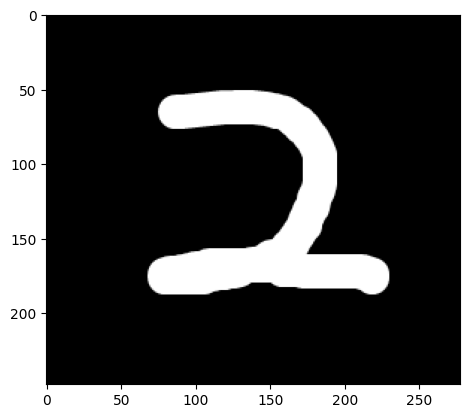

In [ ]:
print(f'prediction: {y_hat}')
image = plt.imread(image_filename)
plt.imshow(image, cmap="gray")
plt.show()

Let's test it with all the custom images.

In [ ]:
!python module8.py "Custom MNIST Samples\\Digit 0\\0_0.png" 0
!python module8.py "Custom MNIST Samples\\Digit 0\\0_1.png" 0
!python module8.py "Custom MNIST Samples\\Digit 0\\0_2.png" 0
!python module8.py "Custom MNIST Samples\\Digit 0\\0_3.png" 0
!python module8.py "Custom MNIST Samples\\Digit 0\\0_4.png" 0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 0\\0_0.png is for digit 0 is recognized as 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 0\\0_1.png is for digit 0 is recognized as 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 0\\0_2.png is for digit 0 is recognized as 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 0\\0_3.png is for digit 0 is recognized as 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 0\\0_4.png is for digit 0 is recognized as 0.


In [ ]:
!python module8.py "Custom MNIST Samples\\Digit 1\\1_0.png" 1
!python module8.py "Custom MNIST Samples\\Digit 1\\1_1.png" 1
!python module8.py "Custom MNIST Samples\\Digit 1\\1_2.png" 1
!python module8.py "Custom MNIST Samples\\Digit 1\\1_3.png" 1
!python module8.py "Custom MNIST Samples\\Digit 1\\1_4.png" 1


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 1\\1_0.png is for digit 1 is recognized as 1.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 1\\1_1.png is for digit 1 is recognized as 1.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 1\\1_2.png is for digit 1 is recognized as 1.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 1\\1_3.png is for digit 1 is recognized as 1.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 1\\1_4.png is for digit 1 is recognized as 1.


In [ ]:
!python module8.py "Custom MNIST Samples\\Digit 2\\2_0.png" 2
!python module8.py "Custom MNIST Samples\\Digit 2\\2_1.png" 2
!python module8.py "Custom MNIST Samples\\Digit 2\\2_2.png" 2
!python module8.py "Custom MNIST Samples\\Digit 2\\2_3.png" 2
!python module8.py "Custom MNIST Samples\\Digit 2\\2_4.png" 2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 2\\2_0.png is for digit 2 is recognized as 2.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 2\\2_1.png is for digit 2 is recognized as 2.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 2\\2_2.png is for digit 2 is recognized as 2.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 2\\2_3.png is for digit 2 is recognized as 2.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 2\\2_4.png is for digit 2 is recognized as 2.


In [ ]:
!python module8.py "Custom MNIST Samples\\Digit 3\\3_0.png" 3
!python module8.py "Custom MNIST Samples\\Digit 3\\3_1.png" 3
!python module8.py "Custom MNIST Samples\\Digit 3\\3_2.png" 3
!python module8.py "Custom MNIST Samples\\Digit 3\\3_3.png" 3
!python module8.py "Custom MNIST Samples\\Digit 3\\3_4.png" 3


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 3\\3_0.png is for digit 3 is recognized as 3.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 3\\3_1.png is for digit 3 is recognized as 3.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 3\\3_2.png is for digit 3 is recognized as 3.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 3\\3_3.png is for digit 3 is recognized as 3.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 3\\3_4.png is for digit 3 is recognized as 3.


In [ ]:
!python module8.py "Custom MNIST Samples\\Digit 4\\4_0.png" 4
!python module8.py "Custom MNIST Samples\\Digit 4\\4_1.png" 4
!python module8.py "Custom MNIST Samples\\Digit 4\\4_2.png" 4
!python module8.py "Custom MNIST Samples\\Digit 4\\4_3.png" 4
!python module8.py "Custom MNIST Samples\\Digit 4\\4_4.png" 4


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 4\\4_0.png is for digit 4 is recognized as 4.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 4\\4_1.png is for digit 4 is recognized as 4.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 4\\4_2.png is for digit 4 is recognized as 4.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 4\\4_3.png is for digit 4 is recognized as 4.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 4\\4_4.png is for digit 4 is recognized as 4.


In [ ]:
!python module8.py "Custom MNIST Samples\\Digit 5\\5_0.png" 5
!python module8.py "Custom MNIST Samples\\Digit 5\\5_1.png" 5
!python module8.py "Custom MNIST Samples\\Digit 5\\5_2.png" 5
!python module8.py "Custom MNIST Samples\\Digit 5\\5_3.png" 5
!python module8.py "Custom MNIST Samples\\Digit 5\\5_4.png" 5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 5\\5_0.png is for digit 5 is recognized as 5.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 5\\5_1.png is for digit 5 is recognized as 5.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 5\\5_2.png is for digit 5 is recognized as 5.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 5\\5_3.png is for digit 5 is recognized as 5.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 5\\5_4.png is for digit 5 is recognized as 5.


In [ ]:
!python module8.py "Custom MNIST Samples\\Digit 6\\6_0.png" 6
!python module8.py "Custom MNIST Samples\\Digit 6\\6_1.png" 6
!python module8.py "Custom MNIST Samples\\Digit 6\\6_2.png" 6
!python module8.py "Custom MNIST Samples\\Digit 6\\6_3.png" 6
!python module8.py "Custom MNIST Samples\\Digit 6\\6_4.png" 6


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 6\\6_0.png is for digit 6 is recognized as 6.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 6\\6_1.png is for digit 6 is recognized as 6.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Figure(640x480)
Fail: Image Custom MNIST Samples\\Digit 6\\6_2.png is for digit 6 but the inference result is 5.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 6\\6_3.png is for digit 6 is recognized as 6.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 6\\6_4.png is for digit 6 is recognized as 6.


In [ ]:
!python module8.py "Custom MNIST Samples\\Digit 7\\7_0.png" 7
!python module8.py "Custom MNIST Samples\\Digit 7\\7_1.png" 7
!python module8.py "Custom MNIST Samples\\Digit 7\\7_2.png" 7
!python module8.py "Custom MNIST Samples\\Digit 7\\7_3.png" 7
!python module8.py "Custom MNIST Samples\\Digit 7\\7_4.png" 7


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 7\\7_0.png is for digit 7 is recognized as 7.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 7\\7_1.png is for digit 7 is recognized as 7.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 7\\7_2.png is for digit 7 is recognized as 7.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 7\\7_3.png is for digit 7 is recognized as 7.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 7\\7_4.png is for digit 7 is recognized as 7.


In [ ]:
!python module8.py "Custom MNIST Samples\\Digit 8\\8_0.png" 8
!python module8.py "Custom MNIST Samples\\Digit 8\\8_1.png" 8
!python module8.py "Custom MNIST Samples\\Digit 8\\8_2.png" 8
!python module8.py "Custom MNIST Samples\\Digit 8\\8_3.png" 8
!python module8.py "Custom MNIST Samples\\Digit 8\\8_4.png" 8


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 8\\8_0.png is for digit 8 is recognized as 8.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 8\\8_1.png is for digit 8 is recognized as 8.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 8\\8_2.png is for digit 8 is recognized as 8.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Figure(640x480)
Fail: Image Custom MNIST Samples\\Digit 8\\8_3.png is for digit 8 but the inference result is 9.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 8\\8_4.png is for digit 8 is recognized as 8.


In [ ]:
!python module8.py "Custom MNIST Samples\\Digit 9\\9_0.png" 9
!python module8.py "Custom MNIST Samples\\Digit 9\\9_1.png" 9
!python module8.py "Custom MNIST Samples\\Digit 9\\9_2.png" 9
!python module8.py "Custom MNIST Samples\\Digit 9\\9_3.png" 9
!python module8.py "Custom MNIST Samples\\Digit 9\\9_4.png" 9


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 9\\9_0.png is for digit 9 is recognized as 9.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 9\\9_1.png is for digit 9 is recognized as 9.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 9\\9_2.png is for digit 9 is recognized as 9.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 9\\9_3.png is for digit 9 is recognized as 9.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Figure(640x480)
Success: Image Custom MNIST Samples\\Digit 9\\9_4.png is for digit 9 is recognized as 9.


In [1]:
import mlflow

In [10]:
best_run_df = mlflow.search_runs(
    experiment_ids='1',
    order_by=["metrics.accuracy ASC"], 
    max_results=1
)

In [11]:
best_run_df

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.accuracy,metrics.validation_loss,metrics.validation_accuracy,metrics.val_loss,...,params.opt_clipnorm,tags.mlflow.parentRunId,tags.mlflow.runName,tags.mlflow.source.name,tags.mlflow.source.git.commit,tags.mlflow.latest_checkpoint_artifact,tags.mlflow.user,tags.mlflow.source.git.repoURL,tags.mlflow.source.git.branch,tags.mlflow.source.type
0,bc30f6b53b7f49d8a659a8921b694892,1,FINISHED,mlflow-artifacts:/1/bc30f6b53b7f49d8a659a8921b...,2026-07-16 23:48:53.484000+00:00,2026-07-16 23:49:58.158000+00:00,0.984133,0.056863,0.9818,0.056863,...,None,c94040bca1a14bcfa0b8bf25a64f5a89,trail_b64_e10,leNet_train_track.py,f1b9a5e0e3a05e0a646e8af52b5c14278b815fe0,checkpoints/latest_checkpoint.h5,veliv,https://github.com/vardhan-vvs/LeNet.git,main,LOCAL
